In [ ]:
#imports
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
import os
import zipfile
from sklearn.model_selection import train_test_split

## Testing the Loaded Best Model

This section evaluates the saved best model without retraining. The goal is to confirm that the model can still be loaded successfully and used to make predictions on chest X-ray images in a separate session.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#load saved model
best_model = load_model("/content/drive/MyDrive/pneumonia_project_saved_model/best_pneumonia_model.keras")
print("Model loaded successfully.")
best_model.summary()

Model loaded successfully.


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential_4[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential_4[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    262,272 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │        129 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,275,269 (203.23 MB)

 Trainable params: 14,712,577 (56.12 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

 Optimizer params: 29,425,156 (112.25 MB)

In [ ]:
IMG_SIZE = (224, 224)
THRESHOLD = 0.5

## Testing the Loaded Best Model

This section evaluates the saved best model without retraining. The goal is to confirm that the model can still be loaded successfully and used to make predictions on chest X-ray images in a separate session.

In [ ]:
#extract dataset zip
from google.colab import drive
drive.mount('/content/drive')
zip_path = "/content/drive/MyDrive/combined_dataset.zip"
extract_dir = "/content/combined_dataset"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted to:", extract_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted to: /content/combined_dataset


In [ ]:
data_dir = "/content/combined_dataset/combined_dataset"
print(os.listdir(data_dir))

['PNEUMONIA', 'NORMAL']


In [ ]:
#rebuild dataframe
filepaths = []
labels = []

for label_name in os.listdir(data_dir):
    label_folder = os.path.join(data_dir, label_name)
    if os.path.isdir(label_folder):
        for fname in os.listdir(label_folder):
            fpath = os.path.join(label_folder, fname)
            filepaths.append(fpath)
            labels.append(label_name)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print(df.head())
print(df["label"].value_counts())

                                            filepath      label
0  /content/combined_dataset/combined_dataset/PNE...  PNEUMONIA
1  /content/combined_dataset/combined_dataset/PNE...  PNEUMONIA
2  /content/combined_dataset/combined_dataset/PNE...  PNEUMONIA
3  /content/combined_dataset/combined_dataset/PNE...  PNEUMONIA
4  /content/combined_dataset/combined_dataset/PNE...  PNEUMONIA
label
PNEUMONIA    4567
NORMAL       2079
Name: count, dtype: int64


In [ ]:
#recreate train, val, test splits
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 4652
Validation size: 997
Test size: 997


## Define a Prediction Function

The following function preprocesses a chest X-ray image, applies the saved best model, and returns the predicted class together with the pneumonia probability.

In [ ]:
#prediction function
def predict_xray(image_path, model, img_size=IMG_SIZE, threshold=THRESHOLD, show_image=True):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize(img_size)

    img_array = np.array(img_resized).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_prob = float(model.predict(img_array, verbose=0)[0][0])
    pred_label = "PNEUMONIA" if pred_prob >= threshold else "NORMAL"

    if show_image:
        plt.figure(figsize=(5, 5))
        plt.imshow(img_resized, cmap="gray")
        plt.axis("off")
        plt.title(
            f"Prediction: {pred_label}\nP(PNEUMONIA) = {pred_prob:.3f} | P(NORMAL) = {1 - pred_prob:.3f}",
            fontweight="bold"
        )
        plt.show()

    return pred_label, pred_prob

## Test the Loaded Model on One Example Image

This is a quick sanity check to confirm that the saved model can be used for inference without retraining.

Testing image: /content/combined_dataset/combined_dataset/NORMAL/nih_00017981_004.png
True label: NORMAL


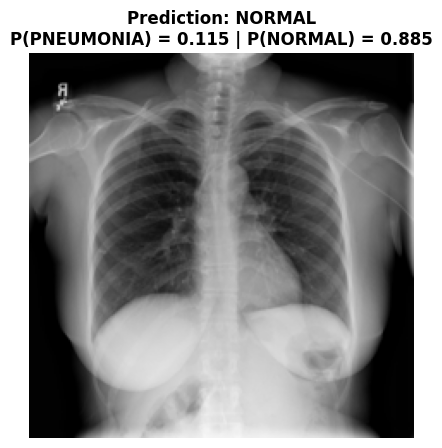

Predicted label: NORMAL
Predicted pneumonia probability: 0.1152
Correct prediction: True


In [ ]:
# test one image
example_row = test_df.iloc[89]

example_image_path = example_row["filepath"]
true_label = example_row["label"]

print("Testing image:", example_image_path)
print("True label:", true_label)

pred_label, pred_prob = predict_xray(example_image_path, best_model)
print("Predicted label:", pred_label)
print("Predicted pneumonia probability:", round(pred_prob, 4))
print("Correct prediction:", pred_label == true_label)

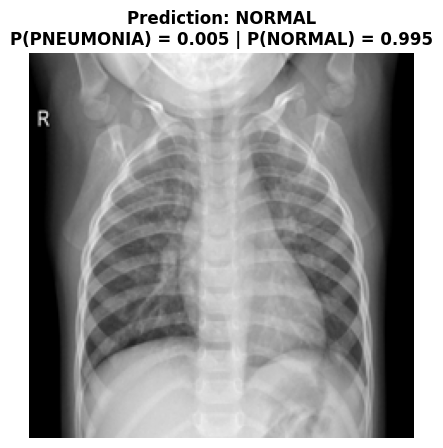

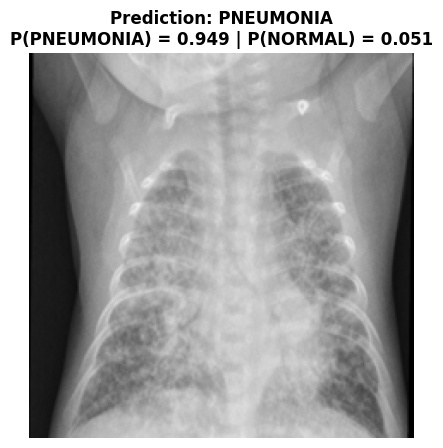

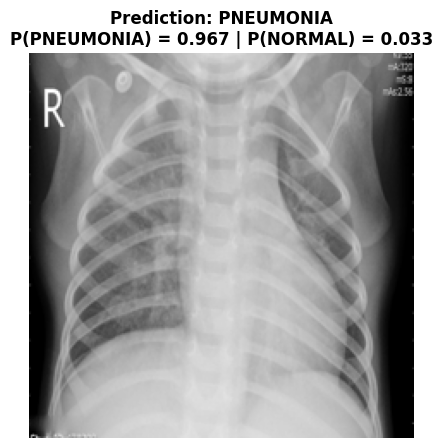

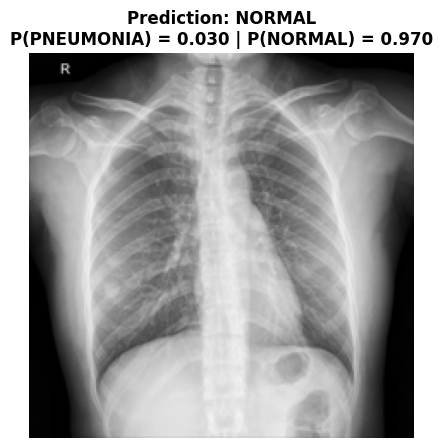

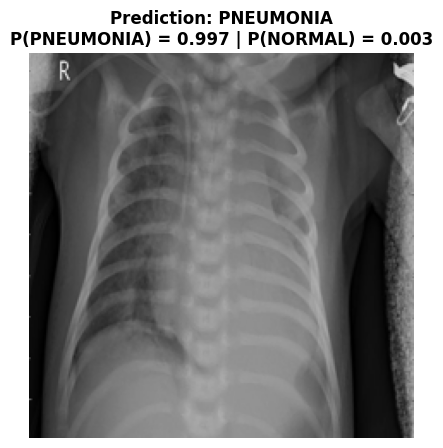

,filepath,true_label,predicted_label,p_pneumonia,p_normal,correct
0,/content/combined_dataset/combined_dataset/NOR...,NORMAL,NORMAL,0.004556,0.995444,True
1,/content/combined_dataset/combined_dataset/PNE...,PNEUMONIA,PNEUMONIA,0.948768,0.051232,True
2,/content/combined_dataset/combined_dataset/PNE...,PNEUMONIA,PNEUMONIA,0.966553,0.033447,True
3,/content/combined_dataset/combined_dataset/NOR...,NORMAL,NORMAL,0.030455,0.969545,True
4,/content/combined_dataset/combined_dataset/PNE...,PNEUMONIA,PNEUMONIA,0.996747,0.003253,True


In [ ]:
#test multiple random images
sample_test_df = test_df.sample(5, random_state=42).reset_index(drop=True)

results = []

for _, row in sample_test_df.iterrows():
    true_label = row["label"]
    image_path = row["filepath"]

    pred_label, pred_prob = predict_xray(image_path, best_model, show_image=True)

    results.append({
        "filepath": image_path,
        "true_label": true_label,
        "predicted_label": pred_label,
        "p_pneumonia": pred_prob,
        "p_normal": 1 - pred_prob,
        "correct": true_label == pred_label
    })

results_df = pd.DataFrame(results)
results_df

## Explainability with Grad-CAM

Grad-CAM is applied to the saved best model to visualize the image regions that most influenced the model’s prediction. Since the loaded best model uses a fine-tuned ResNet50 backbone, the Grad-CAM implementation below is tailored specifically to ResNet50.

In [ ]:
#GradCAM helper functions
def get_model_family(model_name):
    name = model_name.lower()
    if "baseline" in name:
        return "baseline"
    elif "resnet" in name:
        return "resnet"
    elif "densenet" in name:
        return "densenet"
    elif "efficientnet" in name:
        return "efficientnet"
    else:
        raise ValueError(f"Unknown model family: {model_name}")

In [ ]:
#Crop-aware image loader
# This helps reduce attention to borders and non-lung areas.
def load_image_for_gradcam(img_path, target_size=IMG_SIZE, crop=True):
    img = Image.open(img_path).convert("RGB")

    if crop:
        w, h = img.size
        left = int(w * 0.10)
        right = int(w * 0.90)
        top = int(h * 0.12)
        bottom = int(h * 0.95)
        img = img.crop((left, top, right, bottom))

    img_resized = img.resize(target_size)
    img_array = np.array(img_resized).astype("float32") / 255.0
    batched = np.expand_dims(img_array, axis=0)

    return img, img_array, batched

In [ ]:
best_model_name = "ResNet50 Fine-Tuned"

In [ ]:
def overlay_gradcam(img_array, heatmap, alpha=0.25):
    heatmap_uint8 = np.uint8(255 * heatmap)

    jet = plt.colormaps["jet"]
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_array.shape[1], img_array.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap) / 255.0

    superimposed_img = jet_heatmap * alpha + img_array
    superimposed_img = np.clip(superimposed_img, 0, 1)

    return superimposed_img

In [ ]:
def make_gradcam_heatmap_resnet(img_array, model, target_layer_name="conv4_block6_out"):
    resnet_backbone = model.get_layer("resnet50")
    target_layer = resnet_backbone.get_layer(target_layer_name)

    backbone_grad_model = tf.keras.models.Model(
        inputs=resnet_backbone.input,
        outputs=[target_layer.output, resnet_backbone.output]
    )

    backbone_idx = None
    for i, layer in enumerate(model.layers):
        if layer.name == "resnet50":
            backbone_idx = i
            break

    img_tensor = tf.cast(img_array, tf.float32)

    x = img_tensor
    for layer in model.layers:
        if layer.name == "resnet50":
            break
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
        x = layer(x, training=False)

    with tf.GradientTape() as tape:
        conv_outputs, backbone_output = backbone_grad_model(x, training=False)
        tape.watch(conv_outputs)

        y = backbone_output
        for layer in model.layers[backbone_idx + 1:]:
            y = layer(y, training=False)

        preds = y
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [ ]:
def run_resnet_gradcam(img_path, model, target_layer_name="conv4_block6_out", crop=True):
    _, img_array, batched_img = load_image_for_gradcam(img_path, crop=crop)

    heatmap = make_gradcam_heatmap_resnet(
        img_array=batched_img,
        model=model,
        target_layer_name=target_layer_name
    )

    overlay = overlay_gradcam(img_array, heatmap, alpha=0.25)

    pred_prob = float(model.predict(batched_img, verbose=0)[0][0])
    pred_label = "PNEUMONIA" if pred_prob >= 0.5 else "NORMAL"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_array)
    axes[0].set_title("Original Image", fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(heatmap, cmap="jet", interpolation="bilinear")
    axes[1].set_title(f"Grad-CAM: {target_layer_name}", fontweight="bold")
    axes[1].axis("off")

    axes[2].imshow(overlay, interpolation="bilinear")
    axes[2].set_title(f"Overlay\nPrediction: {pred_label} ({pred_prob:.3f})", fontweight="bold")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## Compare Different ResNet50 Target Layers

Grad-CAM can look different depending on which convolutional layer is used. The following function compares early, middle, and late ResNet50 layers.

In [ ]:
def run_resnet_gradcam_layer_comparison(img_path, model, crop=True):
    _, img_array, batched_img = load_image_for_gradcam(img_path, crop=crop)

    pred_prob = float(model.predict(batched_img, verbose=0)[0][0])
    pred_label = "PNEUMONIA" if pred_prob >= 0.5 else "NORMAL"

    layer_names = ["conv3_block4_out", "conv4_block6_out", "conv5_block3_out"]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img_array)
    axes[0].set_title(f"Original\nPrediction: {pred_label} ({pred_prob:.3f})", fontweight="bold")
    axes[0].axis("off")

    for i, layer_name in enumerate(layer_names, start=1):
        heatmap = make_gradcam_heatmap_resnet(
            img_array=batched_img,
            model=model,
            target_layer_name=layer_name
        )
        axes[i].imshow(heatmap, cmap="jet", interpolation="bilinear")
        axes[i].set_title(layer_name, fontweight="bold")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

## Run Grad-CAM on One Example Image

The example below applies Grad-CAM to a single chest X-ray image using the middle ResNet50 layer `conv4_block6_out`, which often provides a better balance between localization detail and semantic information.

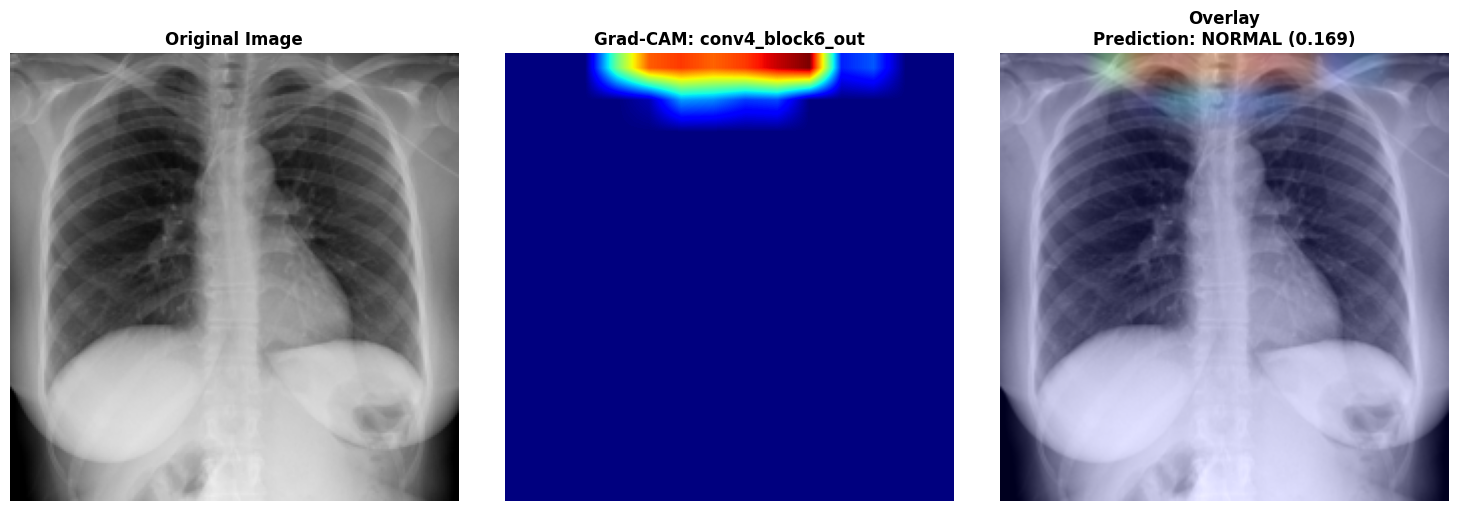

In [ ]:
run_resnet_gradcam(
    img_path=example_image_path,
    model=best_model,
    target_layer_name="conv4_block6_out",
    crop=True
)

## Compare Early, Middle, and Late ResNet50 Layers

This comparison helps determine whether earlier or later convolutional layers provide more meaningful visual explanations.

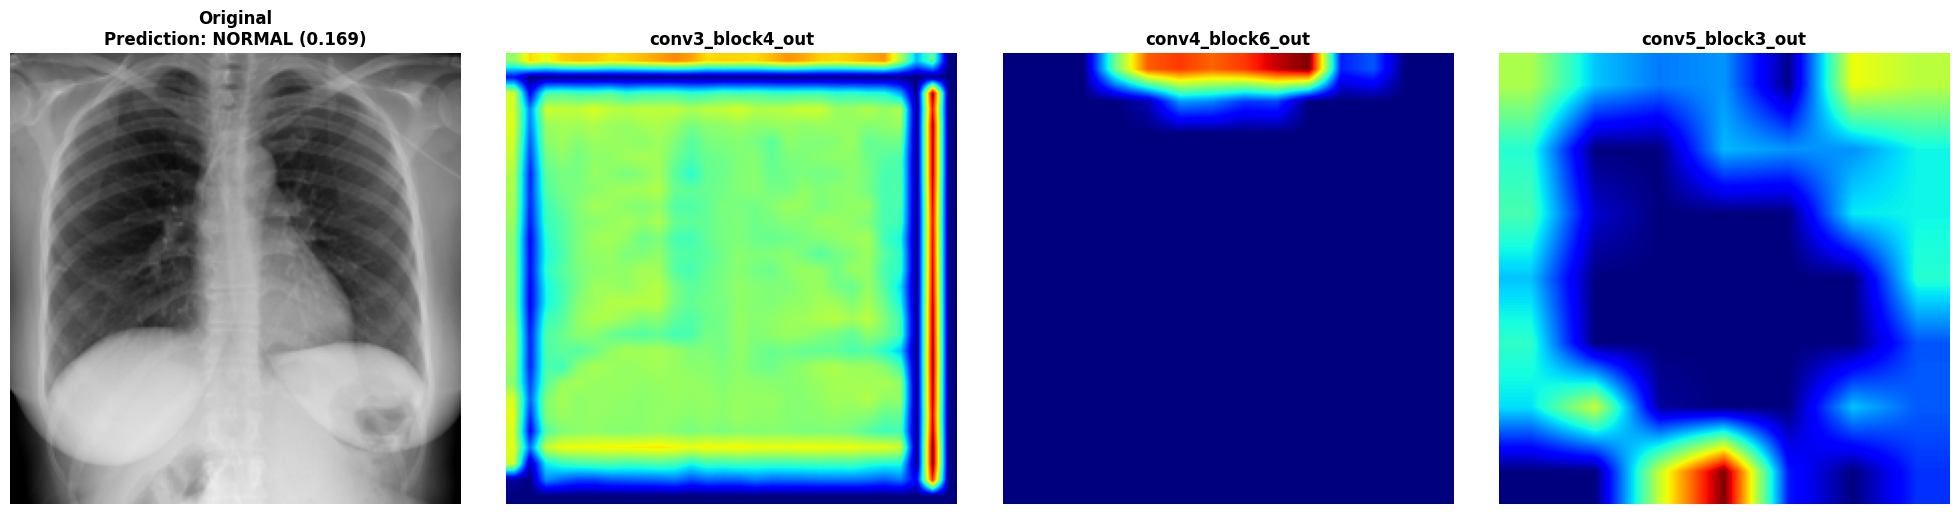

In [ ]:
run_resnet_gradcam_layer_comparison(
    img_path=example_image_path,
    model=best_model,
    crop=True
)

## Identify High-Confidence Correct Predictions

Borderline predictions often produce unclear Grad-CAM heatmaps. Therefore, Grad-CAM is also tested on high-confidence correctly classified images to obtain more interpretable examples.

In [ ]:
def get_prediction_prob(image_path, model):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img_array = np.array(img).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return float(model.predict(img_array, verbose=0)[0][0])

test_df_gradcam = test_df.copy()
test_df_gradcam["pred_prob"] = test_df_gradcam["filepath"].apply(lambda x: get_prediction_prob(x, best_model))
test_df_gradcam["pred_label"] = test_df_gradcam["pred_prob"].apply(lambda p: "PNEUMONIA" if p >= 0.5 else "NORMAL")
test_df_gradcam["correct"] = test_df_gradcam["label"] == test_df_gradcam["pred_label"]

high_conf_examples = test_df_gradcam[
    (
        ((test_df_gradcam["label"] == "PNEUMONIA") & (test_df_gradcam["pred_prob"] >= 0.85)) |
        ((test_df_gradcam["label"] == "NORMAL") & (test_df_gradcam["pred_prob"] <= 0.15))
    ) &
    (test_df_gradcam["correct"])
].reset_index(drop=True)

high_conf_examples[["filepath", "label", "pred_label", "pred_prob"]].head(10)

,filepath,label,pred_label,pred_prob
0,/content/combined_dataset/combined_dataset/PNE...,PNEUMONIA,PNEUMONIA,0.936322
1,/content/combined_dataset/combined_dataset/PNE...,PNEUMONIA,PNEUMONIA,0.999548
2,/content/combined_dataset/combined_dataset/NOR...,NORMAL,NORMAL,0.007088
3,/content/combined_dataset/combined_dataset/PNE...,PNEUMONIA,PNEUMONIA,0.999249
4,/content/combined_dataset/combined_dataset/PNE...,PNEUMONIA,PNEUMONIA,0.993354
5,/content/combined_dataset/combined_dataset/NOR...,NORMAL,NORMAL,0.008179
6,/content/combined_dataset/combined_dataset/NOR...,NORMAL,NORMAL,0.052498
7,/content/combined_dataset/combined_dataset/PNE...,PNEUMONIA,PNEUMONIA,0.968979
8,/content/combined_dataset/combined_dataset/PNE...,PNEUMONIA,PNEUMONIA,0.975878
9,/content/combined_dataset/combined_dataset/PNE...,PNEUMONIA,PNEUMONIA,0.964400


## Run Grad-CAM on High-Confidence Examples

The following code applies Grad-CAM to a few high-confidence correctly classified examples for better visual interpretation.

True label: PNEUMONIA
Predicted probability: 0.9363
File: /content/combined_dataset/combined_dataset/PNEUMONIA/kaggle_person552_bacteria_2313.jpeg


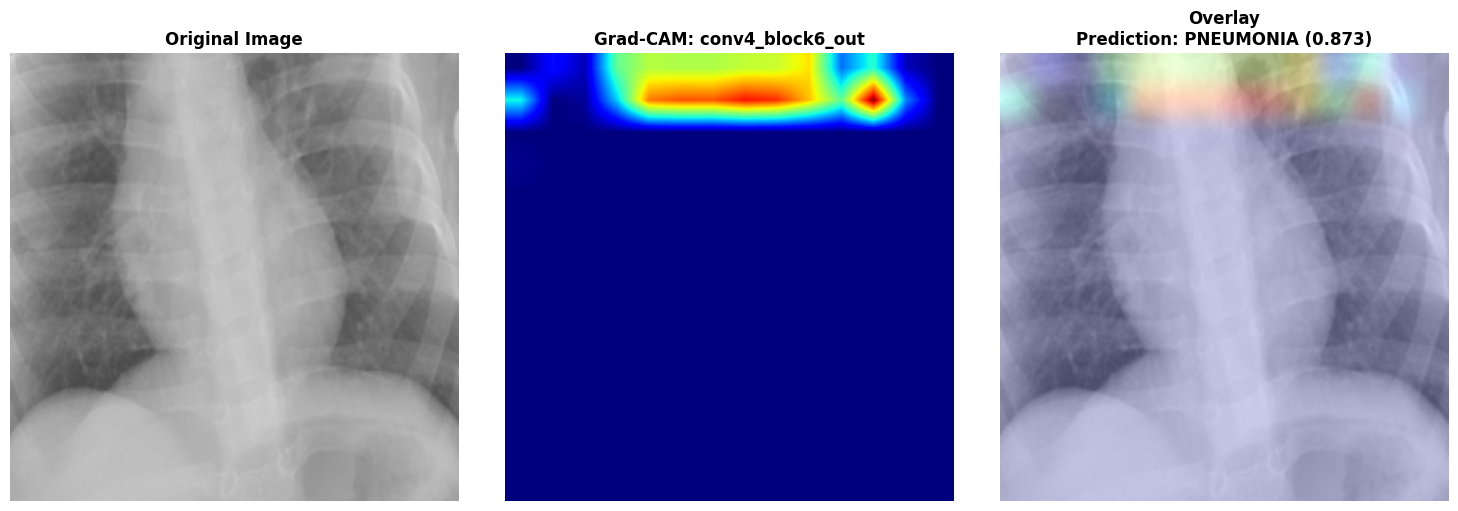

True label: PNEUMONIA
Predicted probability: 0.9995
File: /content/combined_dataset/combined_dataset/PNEUMONIA/kaggle_person402_bacteria_1811.jpeg


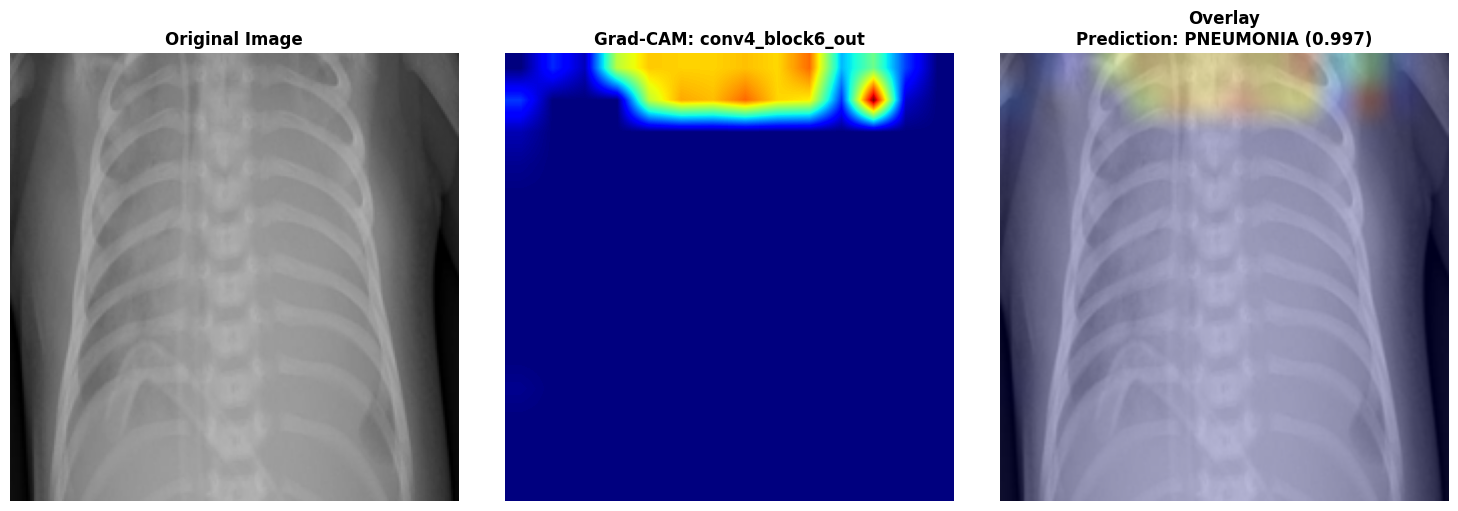

True label: NORMAL
Predicted probability: 0.0071
File: /content/combined_dataset/combined_dataset/NORMAL/kaggle_IM-0501-0001.jpeg


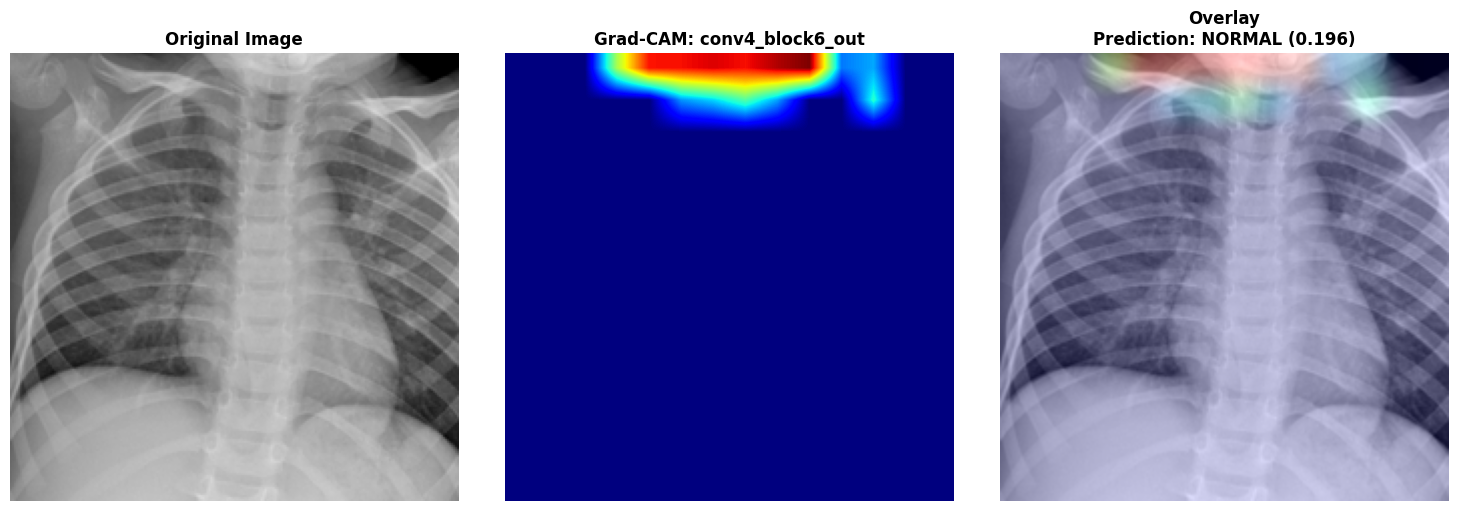

True label: PNEUMONIA
Predicted probability: 0.9992
File: /content/combined_dataset/combined_dataset/PNEUMONIA/kaggle_person319_bacteria_1478.jpeg


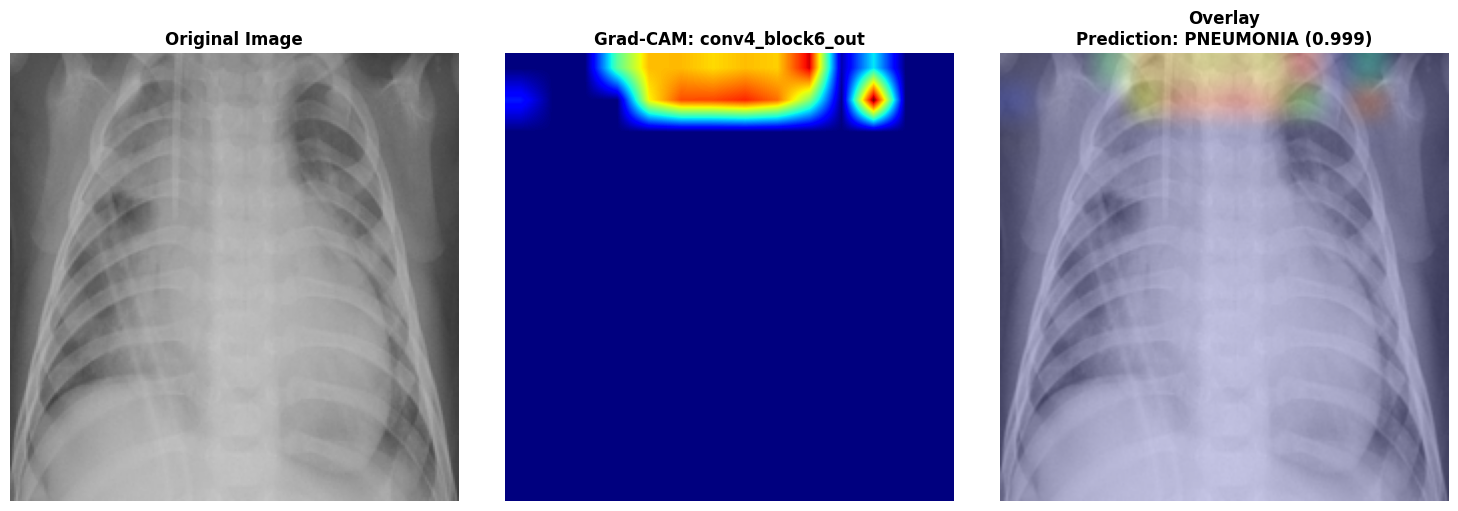

In [ ]:
for _, row in high_conf_examples.head(4).iterrows():
    print("True label:", row["label"])
    print("Predicted probability:", round(row["pred_prob"], 4))
    print("File:", row["filepath"])

    run_resnet_gradcam(
        img_path=row["filepath"],
        model=best_model,
        target_layer_name="conv4_block6_out",
        crop=True
    )

## Interpretation of Grad-CAM Results

Grad-CAM helps assess whether the selected model is focusing on clinically meaningful lung regions when predicting pneumonia. If the highlighted areas are concentrated within the lungs, this suggests more clinically relevant feature use. If attention is focused on borders, upper image regions, or non-lung anatomy, it may indicate shortcut learning or reliance on spurious cues.

Although the selected model achieved strong predictive performance, Grad-CAM visualizations showed that attention was not always concentrated within the lung fields. In several cases, the model focused on image borders, upper image regions, and other non-lung areas. This suggests that the model may have learned dataset-specific shortcuts or spurious visual cues in addition to clinically relevant pneumonia patterns. Therefore, the Grad-CAM results highlight an important limitation of the current model despite its strong classification metrics.

## Save a Grad-CAM Figure

This function saves a Grad-CAM visualization that can be used later in the final report or presentation.

In [ ]:
def save_resnet_gradcam_figure(img_path, model, save_path, target_layer_name="conv4_block6_out", crop=True):
    _, img_array, batched_img = load_image_for_gradcam(img_path, crop=crop)

    heatmap = make_gradcam_heatmap_resnet(
        img_array=batched_img,
        model=model,
        target_layer_name=target_layer_name
    )

    overlay = overlay_gradcam(img_array, heatmap, alpha=0.25)

    pred_prob = float(model.predict(batched_img, verbose=0)[0][0])
    pred_label = "PNEUMONIA" if pred_prob >= 0.5 else "NORMAL"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_array)
    axes[0].set_title("Original Image", fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(heatmap, cmap="jet", interpolation="bilinear")
    axes[1].set_title(f"Grad-CAM: {target_layer_name}", fontweight="bold")
    axes[1].axis("off")

    axes[2].imshow(overlay, interpolation="bilinear")
    axes[2].set_title(f"Overlay\nPrediction: {pred_label} ({pred_prob:.3f})", fontweight="bold")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

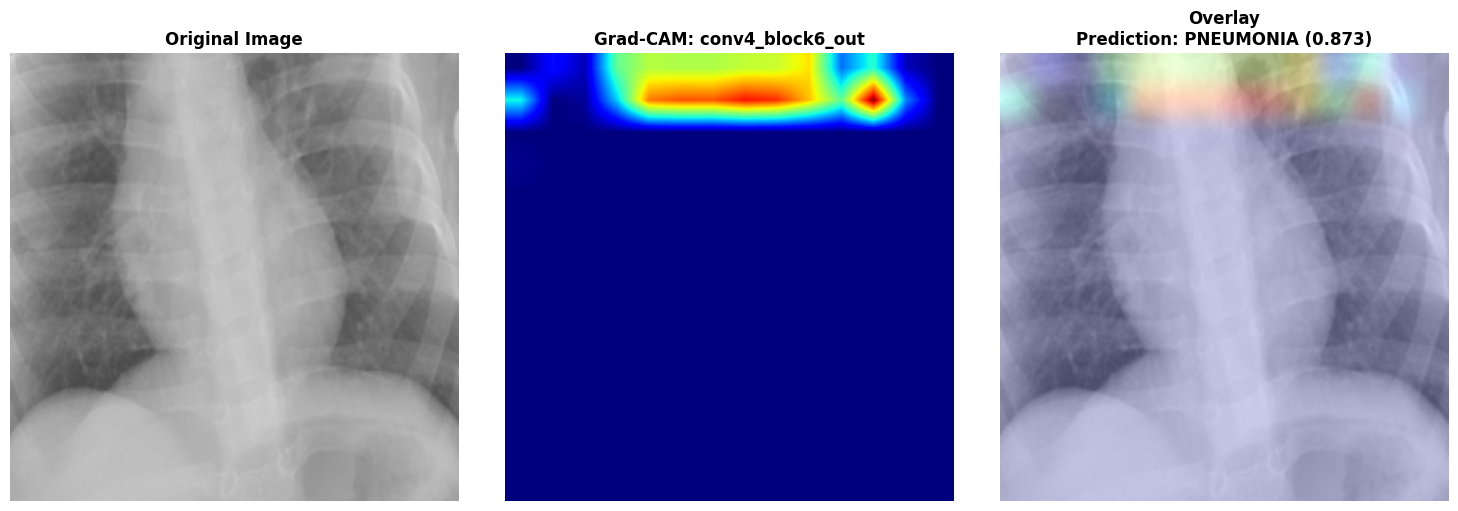

In [ ]:
save_resnet_gradcam_figure(
    img_path=high_conf_examples.iloc[0]["filepath"],
    model=best_model,
    save_path="/content/resnet_gradcam_example.png",
    target_layer_name="conv4_block6_out",
    crop=True
)

In [ ]:
example_image_path = test_df.iloc[78]["filepath"]
print("Testing image:", example_image_path)

pred_label, pred_prob = predict_xray(example_image_path, best_model)
print("Predicted label:", pred_label)
print("Predicted pneumonia probability:", round(pred_prob, 4))